# Comparing growth rates

In this notebook, we look at 3 growth rates

- CAGR: Compounded Annual Growth Rate
- LAGR: Latest Annual Growth Rate
- Thiel-Sen Rate

In [58]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()

True

## Data loading

In [59]:
DATA_DIR = os.getenv("DATA_FOLDER")
RESULTS_DIR = "data"

In [60]:
df = pd.read_csv(os.path.join(DATA_DIR, "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [61]:
all_locations = df["Location"].unique().tolist()

In [62]:
dfs = {}

for loc in tqdm(all_locations):
    if loc == "Scotland":
        continue
    file = f"{loc.replace(' ', '_').lower()}_analysis.xlsx"
    f_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Female")
    m_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Male")

    cols = ["Cause"] + [f"{loc}_{yr}" for yr in range(2014, 2020)]
    f_df = f_df[cols].rename(columns={f"{loc}_{yr}": str(yr) for yr in range(2014, 2020)})
    m_df = m_df[cols].rename(columns={f"{loc}_{yr}": str(yr) for yr in range(2014, 2020)})
    dfs[loc] = {"Male": m_df, "Female": f_df}

100%|██████████| 18/18 [00:00<00:00, 26.10it/s]


## Utilites

In [63]:
NORM_MODES = ["mean", "median", "interval", "base"]

In [64]:
def get_cagr(start, end, years):
    return ((end / (start + 1e-4)) ** (1 / years) - 1)*100

def get_lagr(prev, curr):
    return ((curr - prev) / (prev + 1e-4))*100

def get_pos(N, percentile=50):
    val = (percentile / 100) * (N - 1) # This gives us the position in a 0-indexed list
    return math.floor(val), val

def get_tsq(x, y=None, q=2, norm_mode="mean"):
    # Supports:
    # 1) get_tsq({year: value, ...}, q=2)
    # 2) get_tsq([years...], [values...], q=2)
    if y is None:
        if not isinstance(x, dict):
            raise ValueError("If 'y' is None, 'x' must be a dict of {x: y}.")
        x_arr = np.asarray(list(x.keys()), dtype=float)
        y_arr = np.asarray(list(x.values()), dtype=float)
    else:
        x_arr = np.asarray(x, dtype=float)
        y_arr = np.asarray(y, dtype=float)

    n = x_arr.size
    if n < 2:
        return 0.0

    # All pairwise slopes for i < j (vectorized)
    i, j = np.triu_indices(n, k=1)
    dx = x_arr[j] - x_arr[i]
    dy = y_arr[j] - y_arr[i]
    slopes = dy / dx  # dx != 0 for years

    # Percentile selection
    percentile = 50 if q == 2 else 75 if q == 3 else 50
    order = np.argsort(slopes)
    slopes_sorted = slopes[order]
    i_sorted = i[order]
    j_sorted = j[order]

    m = slopes_sorted.size
    ts_index, weight_val = get_pos(m, percentile)
    frac = weight_val - ts_index

    if ts_index >= m - 1:
        ts_slope = slopes_sorted[-1]
        frac = 0.0
    else:
        ts_slope = slopes_sorted[ts_index] + frac * (slopes_sorted[ts_index + 1] - slopes_sorted[ts_index])

    # Normalization constant
    if norm_mode == "mean":
        norm_const = y_arr.mean()
    elif norm_mode == "median":
        norm_const = np.median(y_arr)
    elif norm_mode == "interval":
        if frac == 0.0 or ts_index >= m - 1:
            t_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            t_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[t_idx].mean()
    elif norm_mode == "base":
        if frac == 0.0 or ts_index >= m - 1:
            t_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            t_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[t_idx].min()
    else:
        raise ValueError("norm_mode must be one of: 'mean', 'median', 'interval'")

    return round(100 * ts_slope / (1e-4 + norm_const), 2)

In [65]:
def get_growth_rates(df, start_yr, end_yr):
    # CAGR
    df["CAGR"] = df.apply(lambda row: get_cagr(row[str(start_yr)], row[str(end_yr)], end_yr - start_yr), axis=1)

    # LAGR
    df["LAGR"] = df.apply(lambda row: get_lagr(row[str(end_yr - 1)], row[str(end_yr)]), axis=1)

    # TSQ
    for norm_mode in NORM_MODES:
        df[f"TSQ_{norm_mode}"] = df.apply(lambda row: get_tsq({yr: row[str(yr)] for yr in range(start_yr, end_yr + 1)}, q=2, norm_mode=norm_mode), axis=1)
    
    return df

def get_predictions(df, end_yr, horizon=1):
    # Get predictions for each method
    df["CAGR_Pred"] = df.apply(lambda row: [row[str(end_yr - 1)] * (1 + row["CAGR"] / 100)**i for i in range(1, horizon + 1)], axis=1)
    df["LAGR_Pred"] = df.apply(lambda row: [row[str(end_yr - 1)] * (1 + row["LAGR"] / 100)**i for i in range(1, horizon + 1)], axis=1)
    for norm_mode in NORM_MODES:
        df[f"TSQ_{norm_mode}_Pred"] = df.apply(lambda row: [row[str(end_yr - 1)] * (1 + row[f"TSQ_{norm_mode}"] / 100)**i for i in range(1, horizon + 1)], axis=1)

    return df

def evaluate_predictions(df, end_yr, horizon=1):
    
    def evaluate_row(row, metric="MAE"):
        actuals = [row[str(end_yr + i)] for i in range(1, horizon + 1)]
        baseline = row[str(end_yr - 1)]*np.ones(horizon)
        cagr_preds = row["CAGR_Pred"]
        lagr_preds = row["LAGR_Pred"]
        tsq_preds = {norm_mode: row[f"TSQ_{norm_mode}_Pred"] for norm_mode in NORM_MODES}

        if metric == "MAE":
            cagr_error = np.mean(np.abs(np.array(cagr_preds) - np.array(actuals)))
            lagr_error = np.mean(np.abs(np.array(lagr_preds) - np.array(actuals)))
            tsq_errors = {norm_mode: np.mean(np.abs(np.array(preds) - np.array(actuals))) for norm_mode, preds in tsq_preds.items()}
        elif metric == "MAPE":
            cagr_error = np.mean(np.abs((np.array(cagr_preds) - np.array(actuals)) / (np.array(actuals) + 1e-4))) * 100
            lagr_error = np.mean(np.abs((np.array(lagr_preds) - np.array(actuals)) / (np.array(actuals) + 1e-4))) * 100
            tsq_errors = {norm_mode: np.mean(np.abs((np.array(preds) - np.array(actuals)) / (np.array(actuals) + 1e-4))) * 100 for norm_mode, preds in tsq_preds.items()}
        elif metric == "SMAPE":
            cagr_error = np.mean(2 * np.abs(np.array(cagr_preds) - np.array(actuals)) / (np.abs(np.array(cagr_preds)) + np.abs(np.array(actuals)))) * 100
            lagr_error = np.mean(2 * np.abs(np.array(lagr_preds) - np.array(actuals)) / (np.abs(np.array(lagr_preds)) + np.abs(np.array(actuals)))) * 100
            tsq_errors = {norm_mode: np.mean(2 * np.abs(np.array(preds) - np.array(actuals)) / (np.abs(np.array(preds)) + np.abs(np.array(actuals)))) * 100 for norm_mode, preds in tsq_preds.items()}
        elif metric == "MASE":
            mae_baseline = np.mean(np.abs(baseline - np.array(actuals)))
            cagr_error = np.mean(np.abs(np.array(cagr_preds) - np.array(actuals))) / (mae_baseline + 1e-4)
            lagr_error = np.mean(np.abs(np.array(lagr_preds) - np.array(actuals))) / (mae_baseline + 1e-4)
            tsq_errors = {norm_mode: (np.mean(np.abs(np.array(preds) - np.array(actuals))) / (mae_baseline + 1e-4)) for norm_mode, preds in tsq_preds.items()}
        else:
            raise ValueError("Unsupported metric. Choose from: 'MAE', 'MAPE', 'SMAPE', 'MASE'.")
        

        return pd.Series({
            "CAGR_Error": cagr_error,
            "LAGR_Error": lagr_error,
            **{f"TSQ_{norm_mode}_Error": error for norm_mode, error in tsq_errors.items()}
        })
    
    # For each metric, get a separate dataframe of errors
    error_dfs = {}
    for metric in ["MAE", "MAPE", "SMAPE", "MASE"]:
        error_df = df.apply(lambda row: evaluate_row(row, metric=metric), axis=1)
        error_dfs[metric] = error_df
    
    return error_dfs

## Goodness of fit

Get the smoothened curve using the growth rates and compare with real curve using RMSE.

In [66]:
def get_curve_rmse(row, start, end, method="CAGR"):
    actuals = row[[str(yr) for yr in range(start, end+1)]].values
    preds = np.array([row[str(start)]*(1 + row[f"{method}"] / 100)**(yr - start) for yr in range(start, end+1)])
    rmse = np.sqrt(np.mean((preds - actuals)**2))
    # rmse = np.mean(np.abs((preds - actuals) / (actuals + 1e-4))) * 100
    # rmse = np.mean(2 * np.abs(preds - actuals) / (np.abs(preds) + np.abs(actuals) + 1e-4)) * 100
    return rmse

avg_rmse = {}
for loc, df_dict in dfs.items():
    avg_rmse[loc] = {}
    for gender, df in df_dict.items():
        # Get the growth rates
        df1 = get_growth_rates(df, start_yr=2014, end_yr=2019)
        df1["CAGR_RMSE"] = df1.apply(lambda row: get_curve_rmse(row, 2014, 2019, method="CAGR"), axis=1)
        df1["LAGR_RMSE"] = df1.apply(lambda row: get_curve_rmse(row, 2014, 2019, method="LAGR"), axis=1)
        for norm_mode in NORM_MODES:
            df1[f"TSQ_{norm_mode}_RMSE"] = df1.apply(lambda row: get_curve_rmse(row, 2014, 2019, method=f"TSQ_{norm_mode}"), axis=1)
        avg_rmse[loc][gender] = {
            "CAGR": df1["CAGR_RMSE"].mean(),
            "LAGR": df1["LAGR_RMSE"].mean(),
            **{f"TSQ_{norm_mode}": df1[f"TSQ_{norm_mode}_RMSE"].mean() for norm_mode in NORM_MODES}
        }

In [67]:
# Visualize RMSE comparison
rmse_df = []
for loc, gender_dict in avg_rmse.items():
    for gender, metrics_dict in gender_dict.items():
        rmse_df.append({
            "Location": loc,
            "Gender": gender,
            **metrics_dict
        })
rmse_df = pd.DataFrame(rmse_df)
rmse_df_melted = rmse_df.melt(id_vars=["Location", "Gender"], var_name="Method", value_name="Avg_RMSE")
rmse_df_melted.head()

,Location,Gender,Method,Avg_RMSE
0,East Scotland,Male,CAGR,34.539438
1,East Scotland,Female,CAGR,25.608346
2,West Scotland,Male,CAGR,29.021410
3,West Scotland,Female,CAGR,21.254006
4,North Scotland,Male,CAGR,31.484531


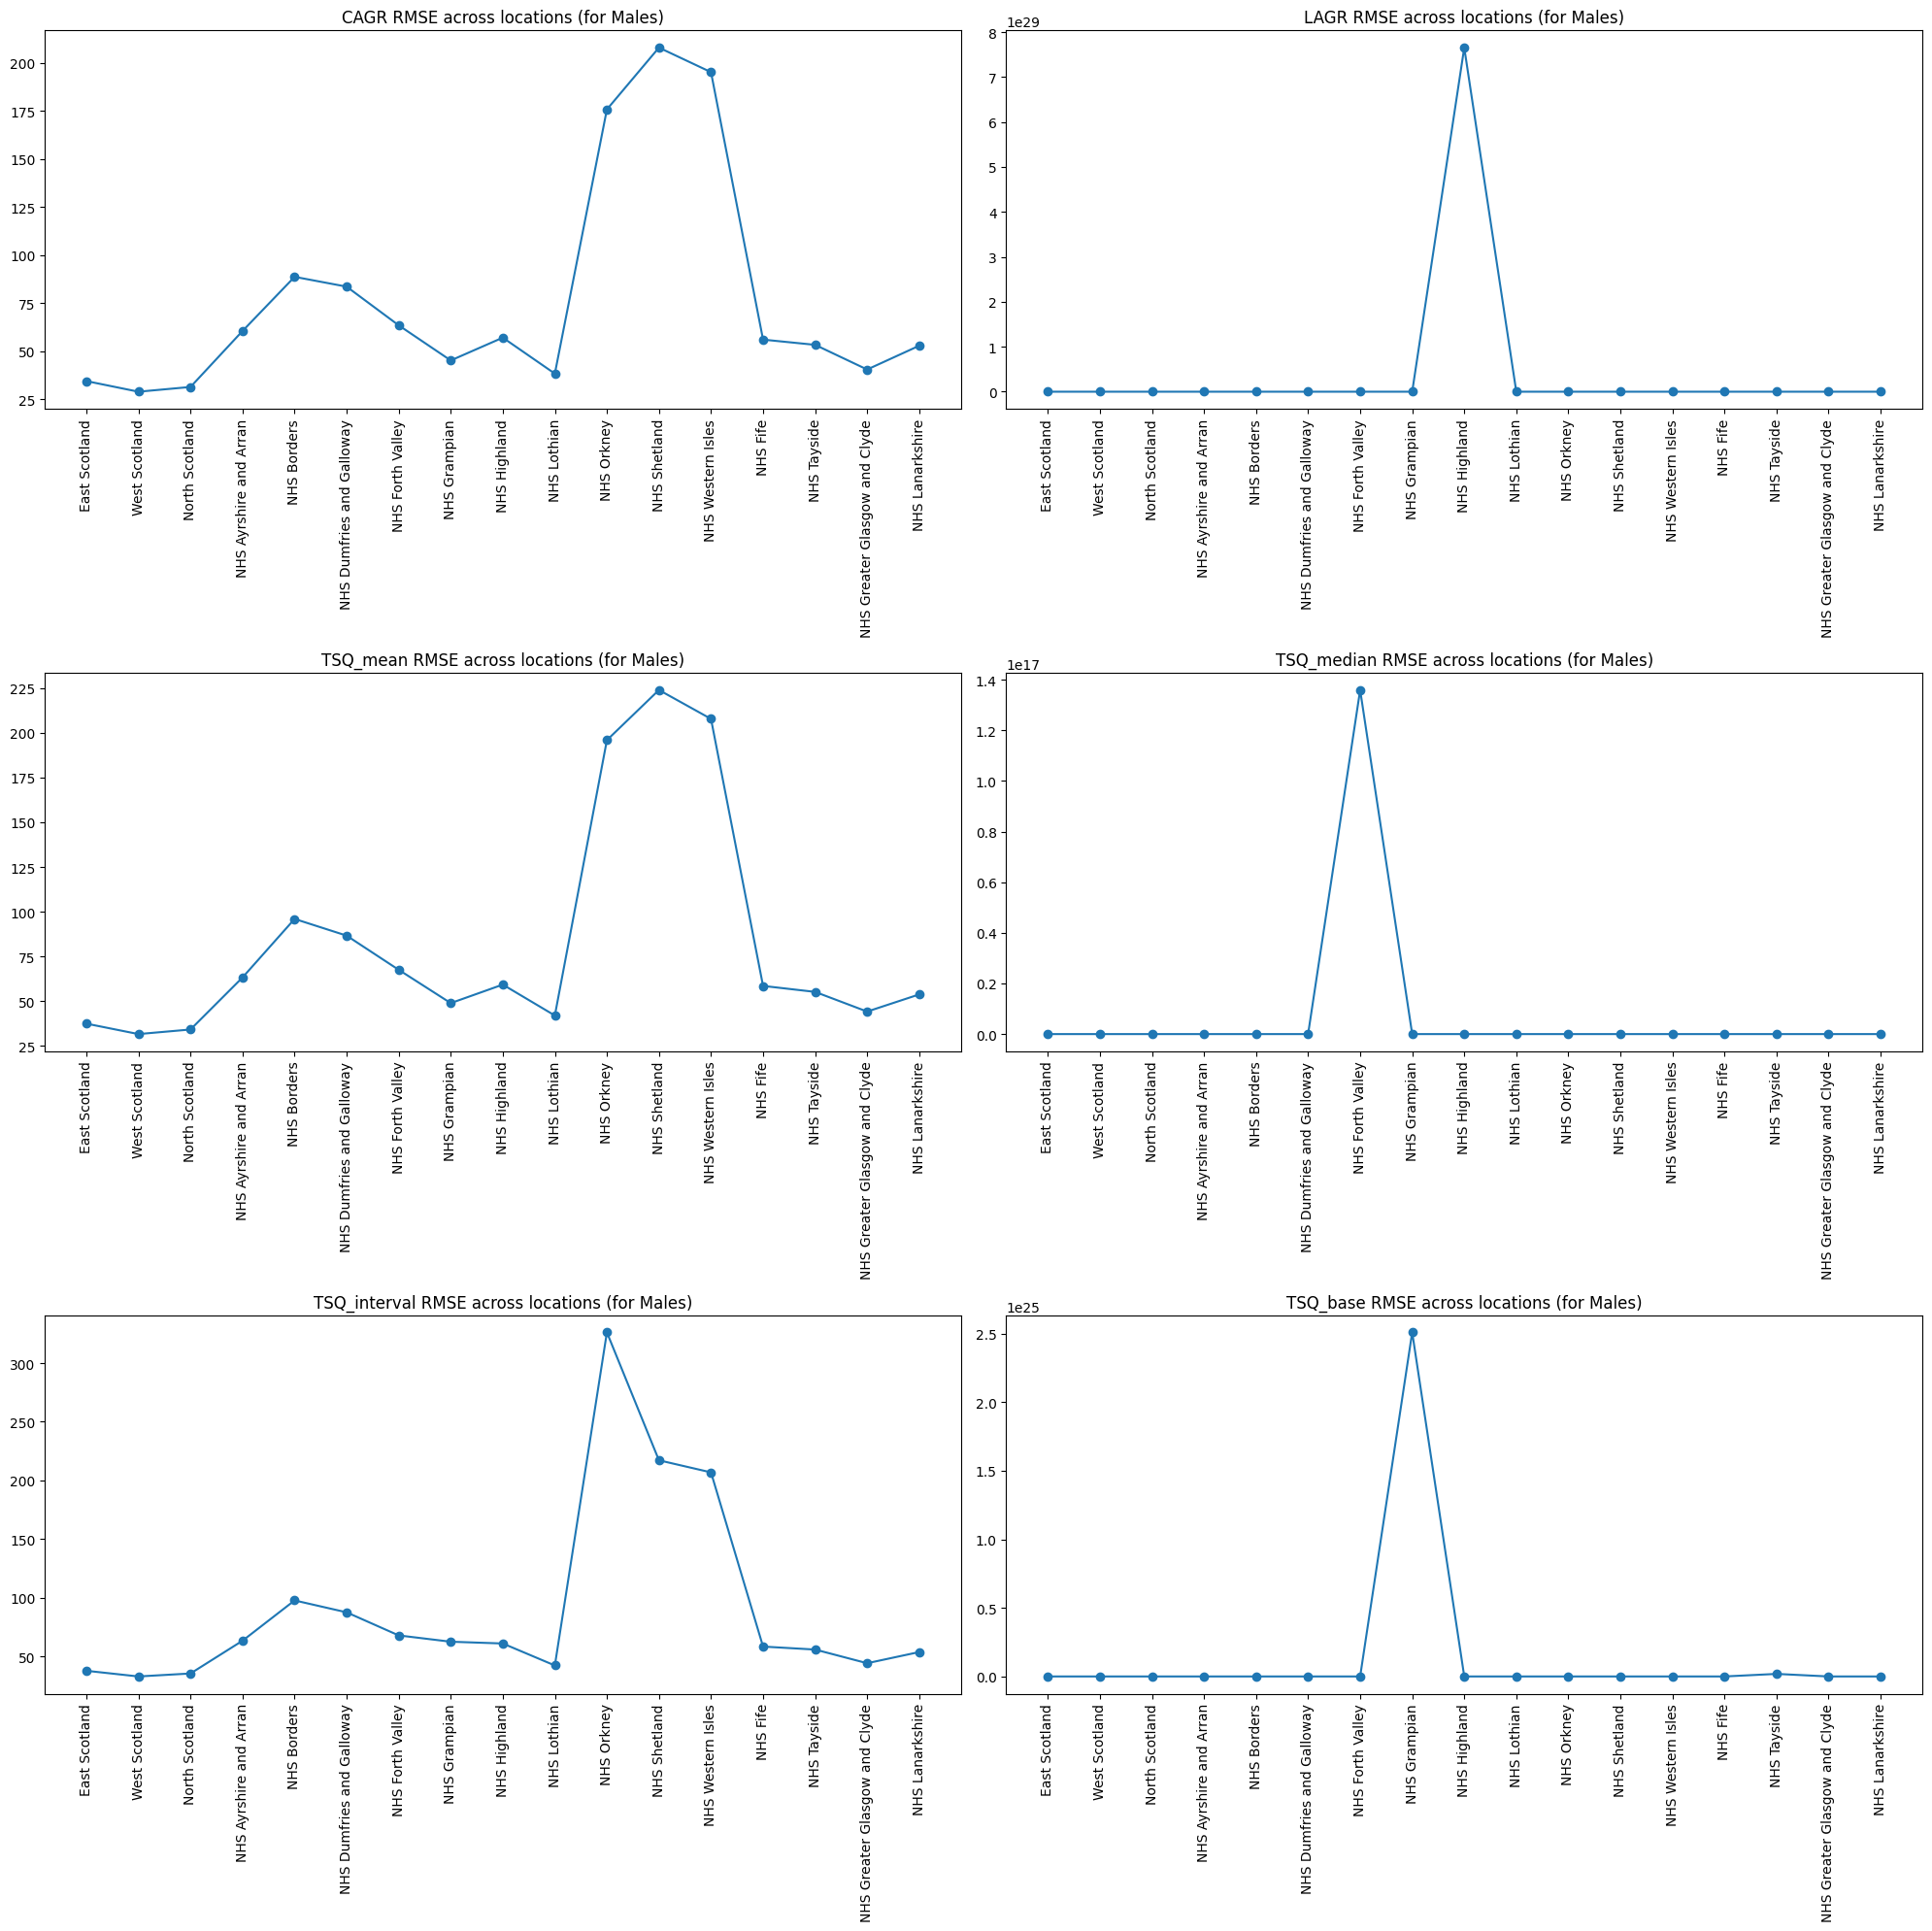

In [68]:
rows, cols = 3, 2
fig, axs = plt.subplots(rows, cols, figsize=(20, 20))

for i, method in enumerate(["CAGR", "LAGR"] + [f"TSQ_{norm_mode}" for norm_mode in NORM_MODES]):
    rmse_df_sub = rmse_df_melted[(rmse_df_melted["Method"] == method) & (rmse_df_melted["Gender"]=="Male")]
    ax = axs[i // cols, i % cols]
    vals = rmse_df_sub["Avg_RMSE"].values
    ax.plot(list(range(len(vals))), vals, marker='o')
    ax.set_title(f"{method} RMSE across locations (for Males)")
    ax.set_xticks(list(range(len(vals))))
    ax.set_xticklabels(rmse_df_sub["Location"].values, rotation=90)
plt.tight_layout()
plt.show()

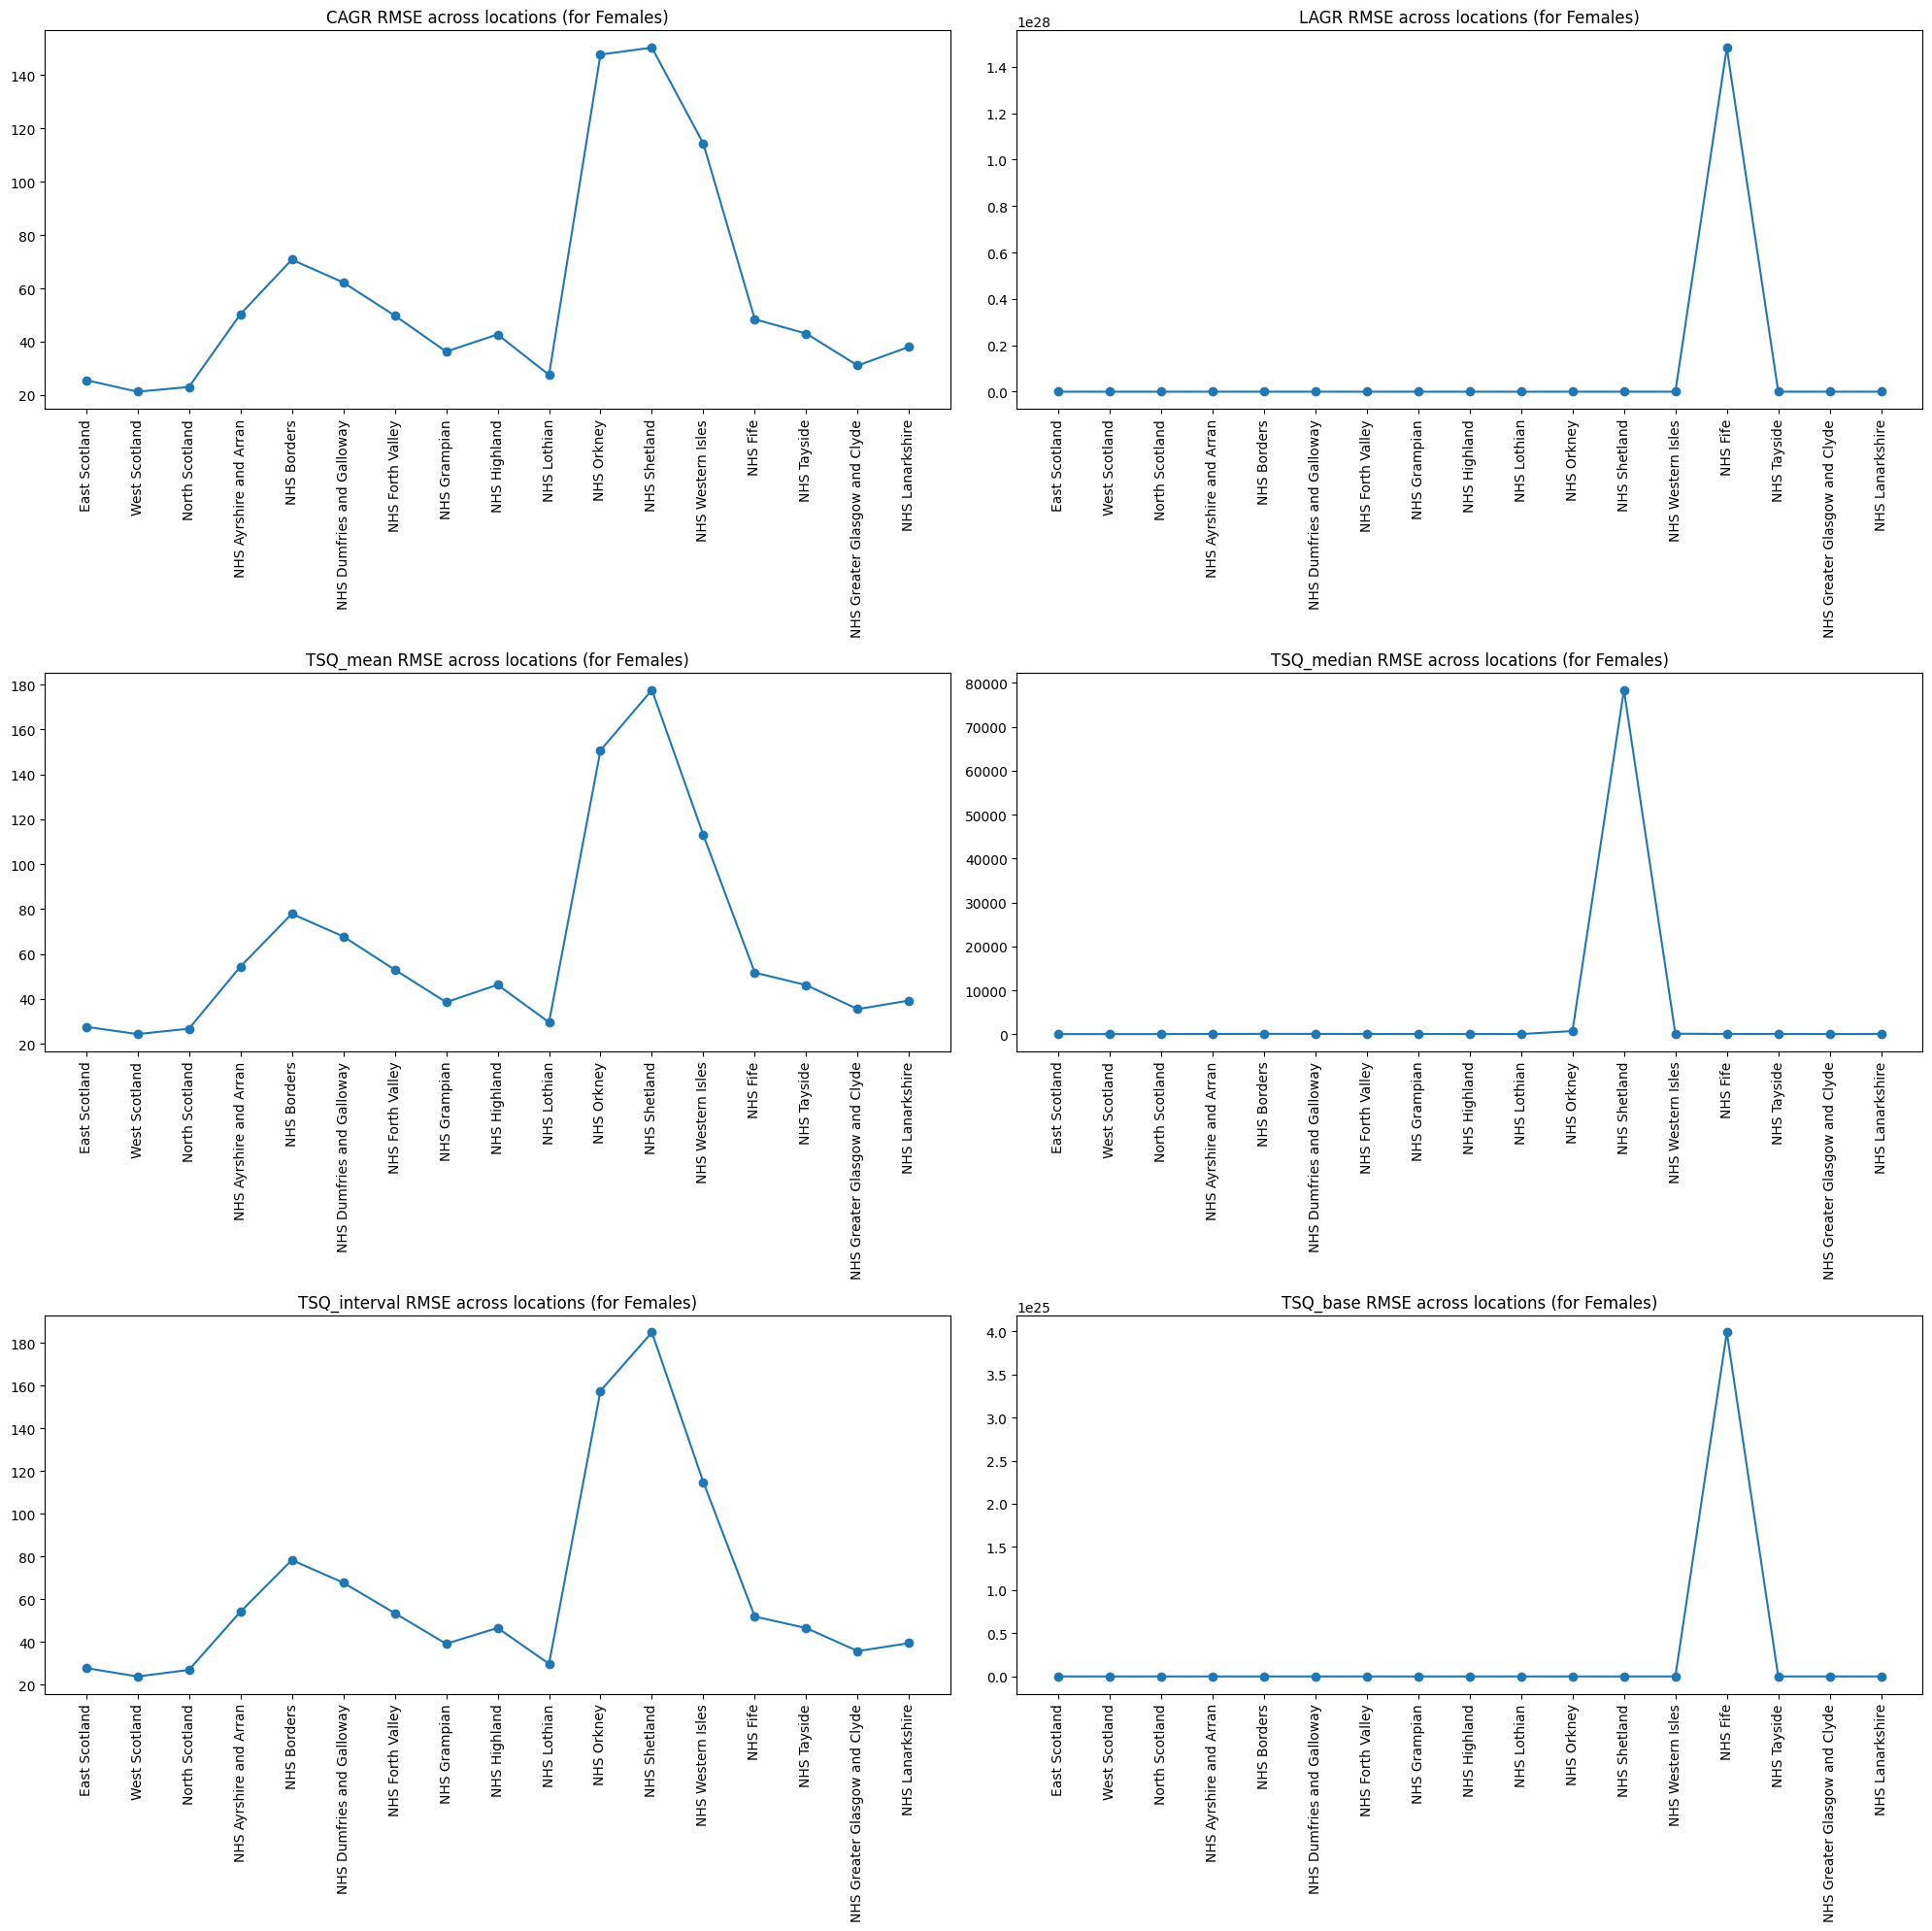

In [69]:
rows, cols = 3, 2
fig, axs = plt.subplots(rows, cols, figsize=(20, 20))

for i, method in enumerate(["CAGR", "LAGR"] + [f"TSQ_{norm_mode}" for norm_mode in NORM_MODES]):
    rmse_df_sub = rmse_df_melted[(rmse_df_melted["Method"] == method) & (rmse_df_melted["Gender"]=="Female")]
    ax = axs[i // cols, i % cols]
    vals = rmse_df_sub["Avg_RMSE"].values
    ax.plot(list(range(len(vals))), vals, marker='o')
    ax.set_title(f"{method} RMSE across locations (for Females)")
    ax.set_xticks(list(range(len(vals))))
    ax.set_xticklabels(rmse_df_sub["Location"].values, rotation=90)
plt.tight_layout()
plt.show()

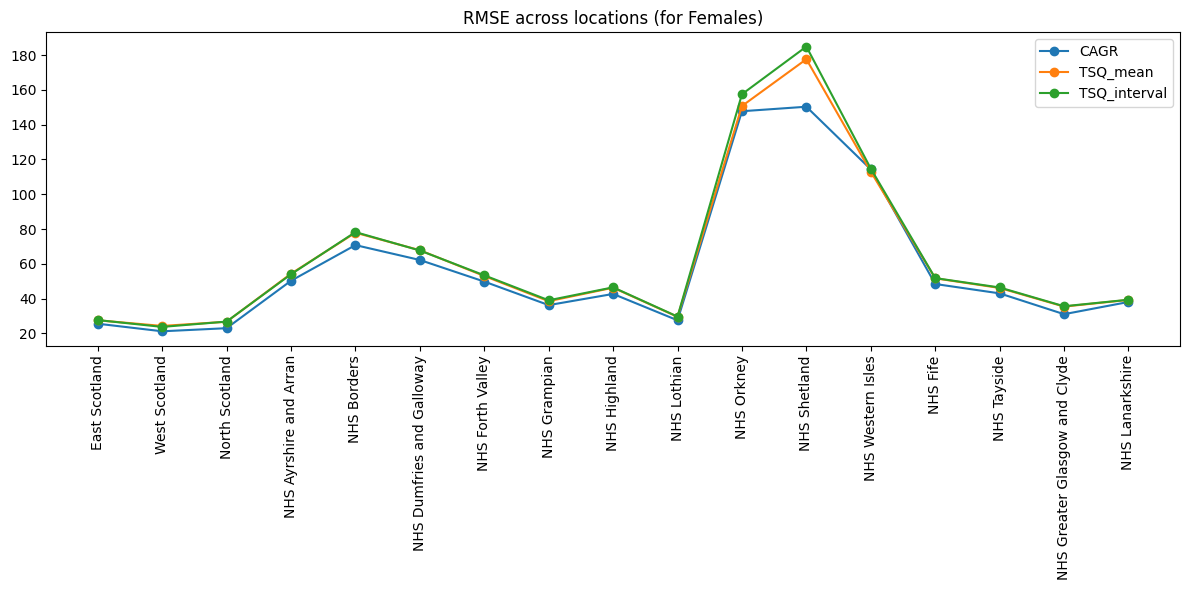

In [70]:
# Plot CAGR, TSQ_mean and TSQ_interval avg rmse in same plot for all locations
fig, ax = plt.subplots(figsize=(12, 6))
for method in ["CAGR", "TSQ_mean", "TSQ_interval"]:
    rmse_df_sub = rmse_df_melted[(rmse_df_melted["Method"] == method) & (rmse_df_melted["Gender"]=="Female")]
    ax.plot(list(range(len(rmse_df_sub))), rmse_df_sub["Avg_RMSE"].values, marker='o', label=method)
ax.set_title("RMSE across locations (for Females)")
ax.set_xticks(list(range(len(rmse_df_sub))))
ax.set_xticklabels(rmse_df_sub["Location"].values, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

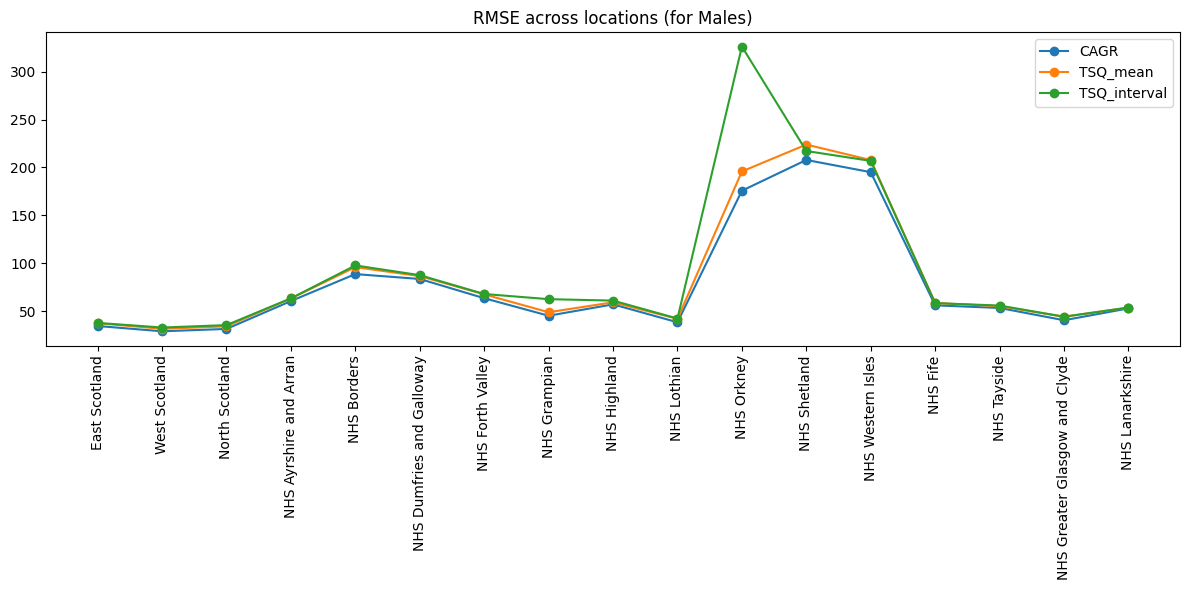

In [71]:
# Plot CAGR, TSQ_mean and TSQ_interval avg rmse in same plot for all locations
fig, ax = plt.subplots(figsize=(12, 6))
for method in ["CAGR", "TSQ_mean", "TSQ_interval"]:
    rmse_df_sub = rmse_df_melted[(rmse_df_melted["Method"] == method) & (rmse_df_melted["Gender"]=="Male")]
    ax.plot(list(range(len(rmse_df_sub))), rmse_df_sub["Avg_RMSE"].values, marker='o', label=method)
ax.set_title("RMSE across locations (for Males)")
ax.set_xticks(list(range(len(rmse_df_sub))))
ax.set_xticklabels(rmse_df_sub["Location"].values, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

## Testing predictive power

So, here we see how well these growth rates are able to forecast future timesteps. Since we have 6 timesteps in total, we predict next $t$ time steps taking the previous $(6-t)$ timesteps as context and compare the predictive power of the growth rate. Here, we use the baseline as the constant predictor of last historical value that is:
$$
\hat{y}_{t+i} = y_t
$$

where $i > 0$ and $t$ is the last timepoint in history. Since these growth rates are more for history representativeness, our focus is to ballpark estimate and capture trend. So, we use the following metrics:

- **Symmetric Mean Absolute Percentage Error (SMAPE):** Accuracy measure based on percentage (or relative) errors (scale independent). It is expressed as:
$$
SMAPE = \frac{1}{T}\sum_{t=1}^N\frac{|\hat{y}_t - y_t|}{|\hat{y}_t| + |y_t|}
$$

- **Mean Absolute Scaled Error:** It is the mean absolute error of the forecast values, divided by the mean absolute error of the in-sample one-step naive forecast.

Let's demonstrate this for one location then we'll automate for others.

In [9]:
location = all_locations[1]  # Example: "Aberdeen"
location

'East Scotland'

In [18]:
# horizon = 1
start_yr = 2014
end_yr = 2018

df_sample = dfs[location]["Male"]
df1 = get_growth_rates(df_sample, start_yr, end_yr)
df1 = get_predictions(df1, end_yr, horizon=1)
err_df1=evaluate_predictions(df1, end_yr, horizon=1)

/tmp/ipykernel_59765/2385201090.py:41: RuntimeWarning: invalid value encountered in divide
  cagr_error = np.mean(2 * np.abs(np.array(cagr_preds) - np.array(actuals)) / (np.abs(np.array(cagr_preds)) + np.abs(np.array(actuals)))) * 100
/tmp/ipykernel_59765/2385201090.py:42: RuntimeWarning: invalid value encountered in divide
  lagr_error = np.mean(2 * np.abs(np.array(lagr_preds) - np.array(actuals)) / (np.abs(np.array(lagr_preds)) + np.abs(np.array(actuals)))) * 100
/tmp/ipykernel_59765/2385201090.py:43: RuntimeWarning: invalid value encountered in divide
  tsq_errors = {norm_mode: np.mean(2 * np.abs(np.array(preds) - np.array(actuals)) / (np.abs(np.array(preds)) + np.abs(np.array(actuals)))) * 100 for norm_mode, preds in tsq_preds.items()}


In [23]:
# Take mean of errors across all causes for each method
err_df1["MASE"].mean()

CAGR_Error             912.758814
LAGR_Error             716.382675
TSQ_mean_Error        1146.459929
TSQ_median_Error      1162.160585
TSQ_interval_Error    1179.112826
TSQ_base_Error        1219.027841
dtype: float64

In [24]:
# Repeat above steps for all locations and plot catplot - x axis is location y is error hue is method (CAGR, LAGR, TSQ_mean, TSQ_median, TSQ_interval)
combined_error_df = pd.DataFrame()
for loc, df_dict in dfs.items():
    for gender, df in df_dict.items():
        df1 = get_growth_rates(df, start_yr, end_yr)
        df1 = get_predictions(df1, end_yr, horizon=1)
        err_df = evaluate_predictions(df1, end_yr, horizon=1)
        for metric, metric_df in err_df.items():
            metric_df["Location"] = loc
            metric_df["Gender"] = gender
            combined_error_df = pd.concat([combined_error_df, metric_df], ignore_index=True)
sns.catplot(data=combined_error_df, x="Location", y="MASE", hue="Gender", kind="bar")

/tmp/ipykernel_59765/2385201090.py:41: RuntimeWarning: invalid value encountered in divide
  cagr_error = np.mean(2 * np.abs(np.array(cagr_preds) - np.array(actuals)) / (np.abs(np.array(cagr_preds)) + np.abs(np.array(actuals)))) * 100
/tmp/ipykernel_59765/2385201090.py:42: RuntimeWarning: invalid value encountered in divide
  lagr_error = np.mean(2 * np.abs(np.array(lagr_preds) - np.array(actuals)) / (np.abs(np.array(lagr_preds)) + np.abs(np.array(actuals)))) * 100
/tmp/ipykernel_59765/2385201090.py:43: RuntimeWarning: invalid value encountered in divide
  tsq_errors = {norm_mode: np.mean(2 * np.abs(np.array(preds) - np.array(actuals)) / (np.abs(np.array(preds)) + np.abs(np.array(actuals)))) * 100 for norm_mode, preds in tsq_preds.items()}
/tmp/ipykernel_59765/2385201090.py:41: RuntimeWarning: invalid value encountered in divide
  cagr_error = np.mean(2 * np.abs(np.array(cagr_preds) - np.array(actuals)) / (np.abs(np.array(cagr_preds)) + np.abs(np.array(actuals)))) * 100
/tmp/ipykernel_

ValueError: Could not interpret value `MASE` for `y`. An entry with this name does not appear in `data`.